# Аналитические отчеты по закупкам для ритейла (тестовое задание).

## Описание проекта: 
Подготовка отчетов, демонстрирующих распределение заказов по поставщикам и их показатели (страны производства, ассортимент, объем заказа в количественном и денежном выражении) для ритейлера.

Задачи проекта: 
Рассчитать и визуализировать динамику основных показателей поставщиков:
1) отчет по динамике заказов приоритетных поставщиков в формате сводной таблицы:
- количество моделей,
- количество цветомоделей,
- объем заказа (шт),
- объем заказа (USD),
- доля поставщика (% USD),
- средневзвешенная закупочная цена (USD)
2) отчет по изменению закупочных цен в формате сводной таблицы, при условии: расчет должен быть произведен на объемах заказа текущего года, с учетом наличия цветомодели в ассортименте текущего и прошлого годов.
- количество моделей,
- количество цветомоделей,
- объем заказа (шт),
- объем заказа (USD),
- доля поставщика (% USD),
- средневзвешенная закупочная цена (USD),
- отклонение объема заказа, USD
- % отклонения объема заказа USD
Подготовить комментарии к отчетам, визуализировать динамику показателей. 

## Загрузка данных

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
path_to_file = 'C:/Users/Lenovo/Downloads/Задание на знание excel.xlsx'

In [6]:
assortment = pd.read_excel(path_to_file, sheet_name='Assortment')

In [7]:
assortment.head()

,Assortment,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Style,Color,Business Supplier,Primary for Season?,Country,Brand,"TY Quantity, pcs","LY Quantity, pcs"
2,1,MM,Supplier 4,Yes,Vietnam,Brand 2,11500,11500
3,1,N3,Supplier 4,Yes,Vietnam,Brand 2,11500,11500
4,2,S1,Supplier 2,Yes,China,Brand 4,7500,7500


In [8]:
assortment=pd.read_excel(path_to_file, sheet_name='Assortment',
                   header=2,     
                   skiprows=0) 

In [9]:
assortment.head()   

,Style,Color,Business Supplier,Primary for Season?,Country,Brand,"TY Quantity, pcs","LY Quantity, pcs"
0,1,MM,Supplier 4,Yes,Vietnam,Brand 2,11500,11500.0
1,1,N3,Supplier 4,Yes,Vietnam,Brand 2,11500,11500.0
2,2,S1,Supplier 2,Yes,China,Brand 4,7500,7500.0
3,2,X2,Supplier 2,Yes,China,Brand 4,7500,7500.0
4,3,S1,Supplier 2,Yes,China,Brand 4,6500,6500.0


In [10]:
assortment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Style                130 non-null    int64  
 1   Color                130 non-null    object 
 2   Business Supplier    130 non-null    object 
 3   Primary for Season?  130 non-null    object 
 4   Country              130 non-null    object 
 5   Brand                130 non-null    object 
 6   TY Quantity, pcs     130 non-null    int64  
 7   LY Quantity, pcs     125 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 8.2+ KB


Датасет `assortment` представлен 130 строками в 8 столбцах и содержит информацию об ассортименте - моделях и цветах товаров, поставщиках, стране производства, а также количество заказанных экземляров и др., данные и их типы соответствуют описанию, пропуски присутствуют только в столбце LY Quantity и соответствуют моделям, отсутствовавшим в ассортименте прошлого года. 


In [11]:
regions=pd.read_excel(path_to_file, sheet_name='Production region',
                   header=2) 

In [12]:
regions.head()

,Region,Country
0,Bangladesh,Bangladesh
1,China,China
2,China,Hong Kong
3,China,Taiwan
4,Europe,Austria


In [13]:
regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Region   38 non-null     object
 1   Country  38 non-null     object
dtypes: object(2)
memory usage: 736.0+ bytes


Датасет `regions` представлен 38 строками в 2 столбцах и отражает соответствие между странами и регионами производства. Данные и их типы соответствуют описанию, пропуски отсутствуют.

In [14]:
prices=pd.read_excel(path_to_file, sheet_name='Purchase prices',
                   header=2) 

In [15]:
prices.head()

,Style,Production Region,LY Purchase price,LY Currency,TY Purchase price,TY Currency
0,4,Bangladesh,1.10,USD,1.21,USD
1,4,China,7.60,CNY,7.60,CNY
2,4,Europe,0.96,EUR,0.96,EUR
3,4,South Asia,1.11,USD,1.11,USD
4,4,East Asia,1.11,USD,1.11,USD


In [16]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Style              640 non-null    int64  
 1   Production Region  640 non-null    object 
 2   LY Purchase price  640 non-null    float64
 3   LY Currency        640 non-null    object 
 4   TY Purchase price  640 non-null    float64
 5   TY Currency        640 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 30.1+ KB


Датасет `prices` представлен 640 строками и 6 столбцами и содержит информацию о ценах производства моделей в различных регионах за текущий и прошлый год. Данные и их типы соответствуют описанию, пропуски отсутствуют.

In [17]:
rates=pd.read_excel(path_to_file, sheet_name='Rates',
                   header=2) 

In [18]:
rates.head()

,Currency,Exchange Rates to USD
0,CNY,7.1
1,EUR,0.9
2,RUR,95.0


In [19]:
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Currency               3 non-null      object 
 1   Exchange Rates to USD  3 non-null      float64
dtypes: float64(1), object(1)
memory usage: 176.0+ bytes


Датасет `rates` представлен 3 строками и 2 столбцами и содержит информацию о валютных курсах. Данные и их типы соответствуют описанию, пропуски отсутствуют.

Для удобства дальнейших рассчетов переведем в snake case (нижний регистр, вместо пробелов - подчеркивания).

## Присоединения таблиц

In [20]:
for dataset in [assortment,regions,prices,rates]:
    dataset.columns = dataset.columns.str.lower().str.replace(' ', '_').str.replace(',', '').str.replace('?', '')


In [21]:
df=pd.merge(assortment,regions, how='left',on='country')

In [22]:
df=df.merge(prices, left_on=['style','region'], right_on=['style','production_region'], how='left')

In [23]:
df=df.merge(rates,how='left', left_on='ly_currency',right_on='currency')

In [24]:
df=df.drop('currency', axis=1)
df=df.rename(columns={'exchange_rates_to_usd':'ly_rates'})

In [25]:
df=df.merge(rates,how='left', left_on='ty_currency',right_on='currency')
df=df.drop('currency', axis=1)
df=df.rename(columns={'exchange_rates_to_usd':'ty_rates'})


In [26]:
# Заменяем пропуски на 1
df['ly_rates']=df['ly_rates'].fillna(1)
df['ty_rates']=df['ty_rates'].fillna(1)

In [27]:
# Рассчитываем сумму заказа в USD
df['ly_total_usd']=df['ly_purchase_price']/df['ly_rates']*df['ly_quantity_pcs']
df['ty_total_usd']=df['ty_purchase_price']/df['ty_rates']*df['ty_quantity_pcs']

In [28]:
df.head()

,style,color,business_supplier,primary_for_season,country,brand,ty_quantity_pcs,ly_quantity_pcs,region,production_region,ly_purchase_price,ly_currency,ty_purchase_price,ty_currency,ly_rates,ty_rates,ly_total_usd,ty_total_usd
0,1,MM,Supplier 4,Yes,Vietnam,Brand 2,11500,11500.0,Vietnam,Vietnam,2.72,USD,3.264,USD,1.0,1.0,31280.0,37536.0
1,1,N3,Supplier 4,Yes,Vietnam,Brand 2,11500,11500.0,Vietnam,Vietnam,2.72,USD,3.264,USD,1.0,1.0,31280.0,37536.0
2,2,S1,Supplier 2,Yes,China,Brand 4,7500,7500.0,China,China,0.95,USD,0.950,USD,1.0,1.0,7125.0,7125.0
3,2,X2,Supplier 2,Yes,China,Brand 4,7500,7500.0,China,China,0.95,USD,0.950,USD,1.0,1.0,7125.0,7125.0
4,3,S1,Supplier 2,Yes,China,Brand 4,6500,6500.0,China,China,0.91,USD,0.910,USD,1.0,1.0,5915.0,5915.0


In [29]:
df['business_supplier'].unique()

array(['Supplier 4', 'Supplier 2', 'Supplier 3', 'Supplier 1',
       'Supplier 5'], dtype=object)

### Построение отчета по динамике заказов приоритетных поставщиков

In [30]:
primary_suppliers=df[df['primary_for_season']=='Yes'].reset_index(drop=True)
primary_suppliers.head()

,style,color,business_supplier,primary_for_season,country,brand,ty_quantity_pcs,ly_quantity_pcs,region,production_region,ly_purchase_price,ly_currency,ty_purchase_price,ty_currency,ly_rates,ty_rates,ly_total_usd,ty_total_usd
0,1,MM,Supplier 4,Yes,Vietnam,Brand 2,11500,11500.0,Vietnam,Vietnam,2.72,USD,3.264,USD,1.0,1.0,31280.0,37536.0
1,1,N3,Supplier 4,Yes,Vietnam,Brand 2,11500,11500.0,Vietnam,Vietnam,2.72,USD,3.264,USD,1.0,1.0,31280.0,37536.0
2,2,S1,Supplier 2,Yes,China,Brand 4,7500,7500.0,China,China,0.95,USD,0.950,USD,1.0,1.0,7125.0,7125.0
3,2,X2,Supplier 2,Yes,China,Brand 4,7500,7500.0,China,China,0.95,USD,0.950,USD,1.0,1.0,7125.0,7125.0
4,3,S1,Supplier 2,Yes,China,Brand 4,6500,6500.0,China,China,0.91,USD,0.910,USD,1.0,1.0,5915.0,5915.0


In [31]:
report_a = primary_suppliers.groupby('business_supplier').apply(
    lambda x: pd.Series({
        'styles': x['style'].nunique(),
        'color_models': x[['style', 'color']].drop_duplicates().shape[0],
        'ly_quantity_pcs': x['ly_quantity_pcs'].sum(),
        'ty_quantity_pcs': x['ty_quantity_pcs'].sum(),
        'ly_amount_usd': x['ly_total_usd'].sum(),
        'ty_amount_usd': x['ty_total_usd'].sum(),
        'ly_wgt_avg_price': x['ly_total_usd'].sum() / x['ly_quantity_pcs'].sum() if x['ly_quantity_pcs'].sum() > 0 else 0,
        'ty_wgt_avg_price': x['ty_total_usd'].sum() / x['ty_quantity_pcs'].sum() if x['ty_quantity_pcs'].sum() > 0 else 0
    })
)

# Добавляем долю
report_a['ly_share_%'] = (report_a['ly_amount_usd'] / report_a['ly_amount_usd'].sum()) * 100
report_a['ty_share_%'] = (report_a['ty_amount_usd'] / report_a['ty_amount_usd'].sum()) * 100


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_45176\2260470623.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  report_a = primary_suppliers.groupby('business_supplier').apply(


In [32]:
report_a=report_a.round(2)
column_order = ['styles', 
                'color_models', 
                'ly_quantity_pcs', 
                'ty_quantity_pcs', 
                'ly_amount_usd', 
                'ty_amount_usd',
                'ly_share_%',
                'ty_share_%',
                'ly_wgt_avg_price',
                'ty_wgt_avg_price']

report_a = report_a.reindex(columns=column_order)

report_a

,styles,color_models,ly_quantity_pcs,ty_quantity_pcs,ly_amount_usd,ty_amount_usd,ly_share_%,ty_share_%,ly_wgt_avg_price,ty_wgt_avg_price
business_supplier,,,,,,,,,,
Supplier 1,2.0,2.0,40000.0,33300.0,342500.00,285017.90,13.69,10.63,8.56,8.56
Supplier 2,24.0,34.0,318842.0,322342.0,855799.11,874125.96,34.20,32.60,2.68,2.71
Supplier 4,20.0,22.0,229349.0,231849.0,837712.68,1009965.22,33.48,37.66,3.65,4.36
Supplier 5,18.0,21.0,133419.0,148364.0,466247.53,512377.59,18.63,19.11,3.49,3.45


### Визуализация результатов и выводы

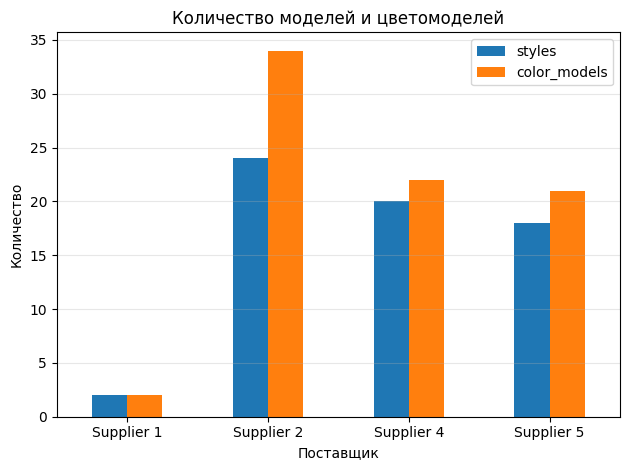

In [33]:
ax = report_a[['styles', 'color_models']].plot(kind='bar', rot=0)
ax.grid(axis='y', alpha=0.3)
plt.title('Количество моделей и цветомоделей')
plt.xlabel('Поставщик')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

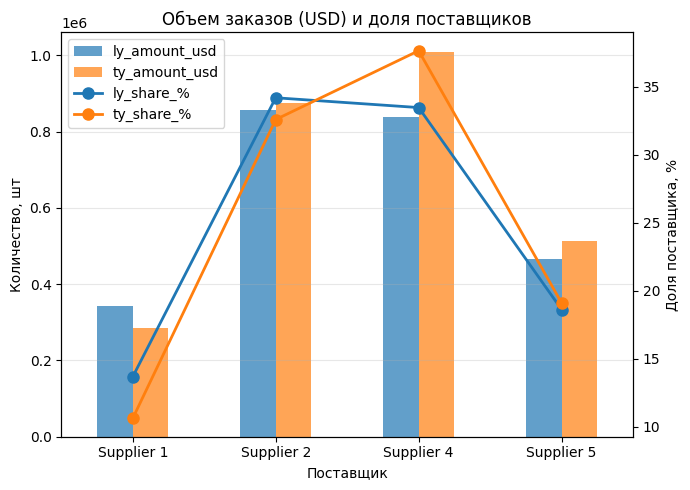

In [34]:
fig, ax1 = plt.subplots(figsize=(7,5))

report_a[['ly_amount_usd', 'ty_amount_usd']].plot(
    kind='bar', ax=ax1, rot=0, alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(report_a['ly_share_%'], 
         marker='o', linewidth=2, markersize=8, label='ly_share_%')
ax2.plot(report_a['ty_share_%'], 
         marker='o', linewidth=2, markersize=8, label='ty_share_%')

ax2.set_ylabel('Доля поставщика, %')
ax1.set_ylabel('Количество, шт')
ax1.set_xlabel('Поставщик')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.title('Объем заказов (USD) и доля поставщиков')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

[Text(0, 0, 'Прошлый год'), Text(1, 0, 'Текущий год')]

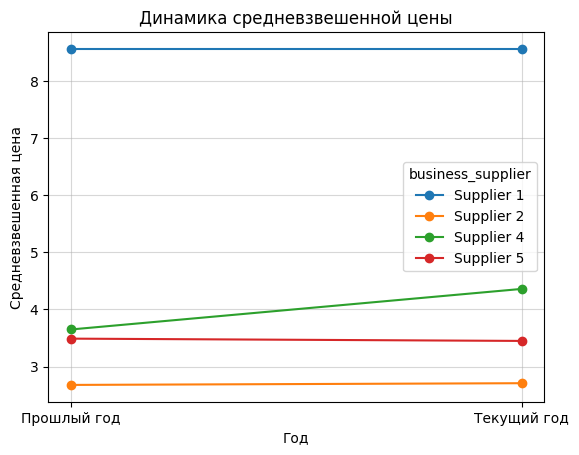

In [35]:
ax=report_a[['ly_wgt_avg_price','ty_wgt_avg_price']].T.plot(
    kind='line', 
    marker='o',
    title='Динамика средневзвешенной цены',
    xlabel='Год',
    ylabel='Средневзвешенная цена'
)
ax.grid(True, alpha=0.5)

ax.set_xticks([0, 1])  
ax.set_xticklabels(['Прошлый год', 'Текущий год'])


In [36]:
report_a

,styles,color_models,ly_quantity_pcs,ty_quantity_pcs,ly_amount_usd,ty_amount_usd,ly_share_%,ty_share_%,ly_wgt_avg_price,ty_wgt_avg_price
business_supplier,,,,,,,,,,
Supplier 1,2.0,2.0,40000.0,33300.0,342500.00,285017.90,13.69,10.63,8.56,8.56
Supplier 2,24.0,34.0,318842.0,322342.0,855799.11,874125.96,34.20,32.60,2.68,2.71
Supplier 4,20.0,22.0,229349.0,231849.0,837712.68,1009965.22,33.48,37.66,3.65,4.36
Supplier 5,18.0,21.0,133419.0,148364.0,466247.53,512377.59,18.63,19.11,3.49,3.45



<div style="border: 5px solid #efa75f; padding: 10px;">

#### Инсайты: 
- Основной драйвер роста суммы закупок — повышение цен (особенно у поставщика 4: +19,5 %).

- Поставщик 4 стал ключевым: его доля выросла до 37,66 %, а рост суммы почти полностью обусловлен ростом цены, а не объёма.

- Закупки у поставщика 1 существенно сокращены (доля −3,06 п. п.).

- Поставщик 5 демонстрирует выгодную динамику: рост объёма при снижении цены.	

#### Краткие рекомендации:
- Проанализировать обоснованность роста цен у поставщика 4 (+19,5 %).

- Выяснить причины сокращения закупок у поставщика 1.

- Рассмотреть возможность расширения сотрудничества с поставщиком 5.

- Снизить зависимость от поставщика 4 из‑за высокой доли (37,6 %).	
</div>									

## Построение отчета по изменению закупочных цен

In [37]:
# Заполним пропуски в столбцах с количеством заказанных товаров на 0. 
df['ly_quantity_pcs']=df['ly_quantity_pcs'].fillna(0)
df['ty_quantity_pcs']=df['ty_quantity_pcs'].fillna(0)

# Отфильтруем только модели, которые присутствовали в ассортименте как текущего, так и прошлого годов
df_both_years=df[(df['ly_quantity_pcs']!=0)&(df['ty_quantity_pcs']!=0)]

In [38]:
report_b = df_both_years.groupby('business_supplier').apply(
    lambda x: pd.Series({
        'styles': x['style'].nunique(),
        'color_models': x[['style', 'color']].drop_duplicates().shape[0],
        'ly_quantity_pcs': x['ly_quantity_pcs'].sum(),
        'ty_quantity_pcs': x['ty_quantity_pcs'].sum(),
        'ly_amount_usd': x['ly_total_usd'].sum(),
        'ty_amount_usd': x['ty_total_usd'].sum(),
        'ly_wgt_avg_price': x['ly_total_usd'].sum() / x['ly_quantity_pcs'].sum() if x['ly_quantity_pcs'].sum() > 0 else 0,
        'ty_wgt_avg_price': x['ty_total_usd'].sum() / x['ty_quantity_pcs'].sum() if x['ty_quantity_pcs'].sum() > 0 else 0
    })
)

report_b['ly_share_%'] = (report_b['ly_amount_usd'] / report_b['ly_amount_usd'].sum()) * 100
report_b['ty_share_%'] = (report_b['ty_amount_usd'] / report_b['ty_amount_usd'].sum()) * 100

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_45176\3717907671.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  report_b = df_both_years.groupby('business_supplier').apply(


In [39]:
report_b = report_b.reindex(columns=column_order)


In [40]:
report_b['order_diff']=report_b['ty_amount_usd']-report_b['ly_amount_usd']
report_b['order_diff_%']=100*(report_b['ty_amount_usd']/report_b['ly_amount_usd']-1)
report_b=report_b.round(2)


In [41]:
report_b

,styles,color_models,ly_quantity_pcs,ty_quantity_pcs,ly_amount_usd,ty_amount_usd,ly_share_%,ty_share_%,ly_wgt_avg_price,ty_wgt_avg_price,order_diff,order_diff_%
business_supplier,,,,,,,,,,,,
Supplier 1,8.0,8.0,94000.0,76944.0,668640.00,545166.73,14.47,11.36,7.11,7.09,-123473.27,-18.47
Supplier 2,34.0,44.0,390724.0,390724.0,1128467.43,1132306.25,24.43,23.59,2.89,2.90,3838.82,0.34
Supplier 3,17.0,18.0,219132.0,219132.0,568285.26,568285.26,12.30,11.84,2.59,2.59,0.00,0.00
Supplier 4,27.0,29.0,317213.0,317213.0,1505708.52,1806850.22,32.60,37.64,4.75,5.70,301141.70,20.00
Supplier 5,24.0,26.0,192750.0,192750.0,748332.50,748332.50,16.20,15.59,3.88,3.88,0.00,0.00


### Визуализация результатов и выводы

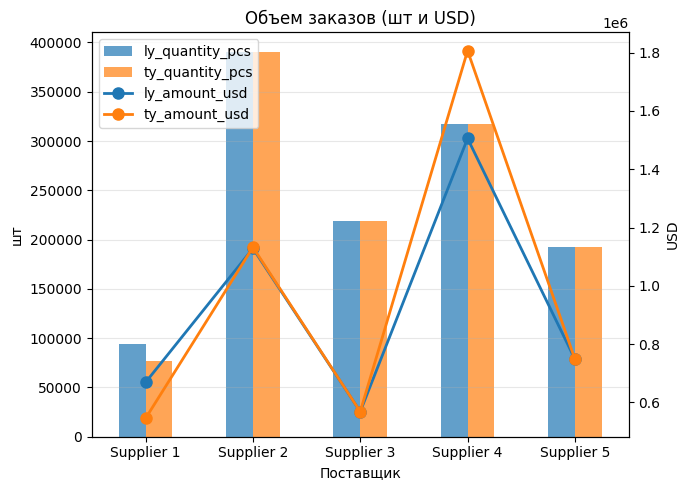

In [42]:
fig, ax1 = plt.subplots(figsize=(7,5))

report_b[['ly_quantity_pcs', 'ty_quantity_pcs']].plot(
    kind='bar', ax=ax1, rot=0, alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(report_b['ly_amount_usd'], 
         marker='o', linewidth=2, markersize=8, label='ly_amount_usd')
ax2.plot(report_b['ty_amount_usd'], 
         marker='o', linewidth=2, markersize=8, label='ty_amount_usd')

ax2.set_ylabel('USD')
ax1.set_ylabel('шт')
ax1.set_xlabel('Поставщик')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.title('Объем заказов (шт и USD)')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

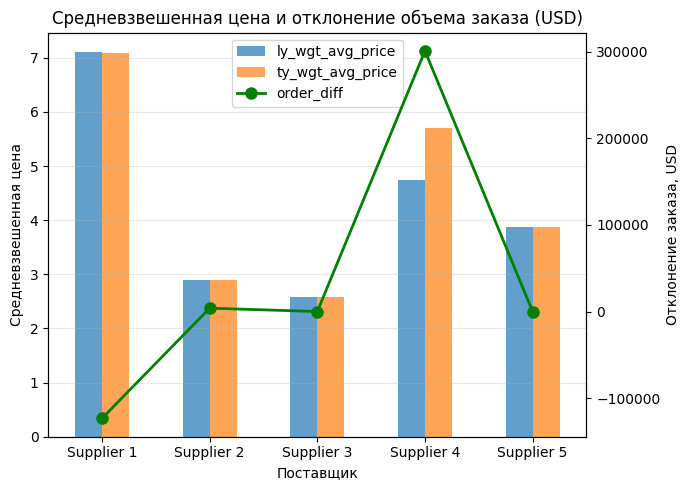

In [43]:
fig, ax1 = plt.subplots(figsize=(7,5))

report_b[['ly_wgt_avg_price', 'ty_wgt_avg_price']].plot(
    kind='bar', ax=ax1, rot=0, alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(report_b['order_diff'], 
         marker='o', linewidth=2, markersize=8, color='green', label='order_diff')

ax2.set_ylabel('Отклонение заказа, USD')
ax1.set_ylabel('Средневзвешенная цена')
ax1.set_xlabel('Поставщик')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

plt.xticks(rotation=45, ha='right')
plt.title('Средневзвешенная цена и отклонение объема заказа (USD)')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

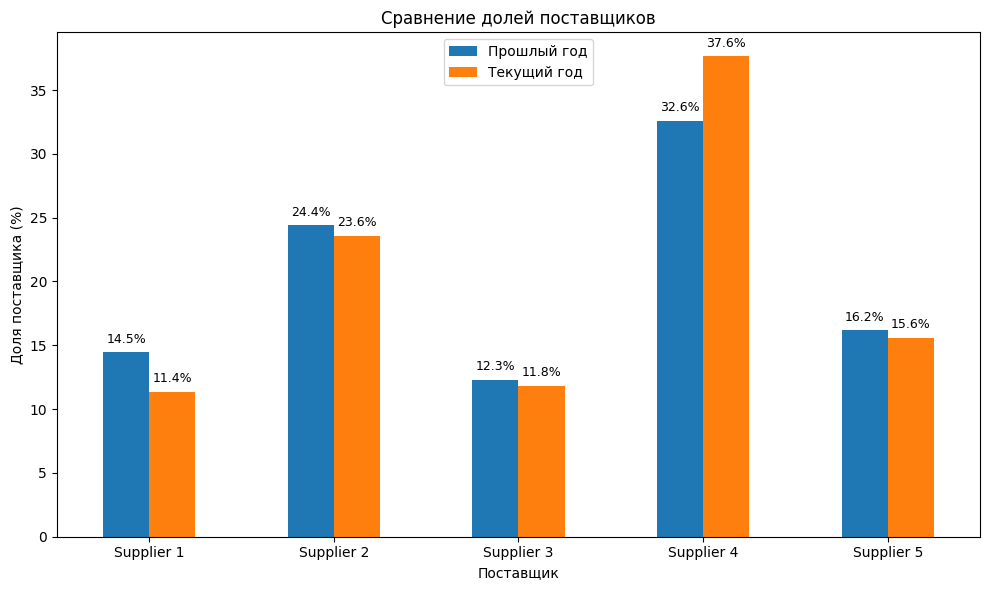

In [44]:
ax = report_b[['ly_share_%', 'ty_share_%']].plot(kind='bar', rot=0, figsize=(10,6))

for i, (container, col_name) in enumerate(zip(ax.containers, ['ly_share_%', 'ty_share_%'])):
    for j, rect in enumerate(container):
        height = rect.get_height()
        if height > 0:
            ax.text(rect.get_x() + rect.get_width()/2., 
                   height + 0.5,
                   f'{height:.1f}%',
                   ha='center', 
                   fontsize=9,                   
                   va='bottom')

plt.title('Сравнение долей поставщиков')
plt.xlabel('Поставщик')
plt.ylabel('Доля поставщика (%)')
plt.legend(['Прошлый год', 'Текущий год'], loc='upper center')
plt.tight_layout()
plt.show()

<div style="border: 5px solid #efa75f; padding: 10px;">

#### Ключевые инсайты:
- Рост суммы закупок (+3,9 %) при сокращении объёма (-1,4 %) вызван повышением цен (+5,2 %).
- Поставщик 4 - главный драйвер роста: +20 % к сумме из‑за скачка цен (+20 %) при неизменном объёме.
- Поставщик 1 - основное сокращение: -18,5 % к сумме и -18,1 % к объёму.
- Поставщики 3 и 5 стабильны по объёму и цене; снижение их долей - следствие роста доли поставщика 4.
- Перераспределение долей: +5 п. п. у поставщика 4, -3,1 п. п. у поставщика 1.
														
#### Краткие рекомендации: 
- Проверить обоснованность роста цен у поставщика 4 (+20 %).
- Выяснить причины сокращения закупок у поставщика 1.
- Рассмотреть возможность оптимизации закупок у поставщиков 2, 3, 5 - они стабильны, но потеряли долю в общем объёме."														
